# Lab 3. Clustering Energy Consumption Patterns for Smart Cities   

#### Objective 
This lab focuses on using clustering techniques to identify patterns in energy consumption data for smart cities. By understanding these patterns, city planners and utility providers can optimize energy distribution, reduce waste, and promote sustainability in urban areas.
#### Problem
Urban areas experience fluctuating energy demands based on factors such as population density, time of day, and weather conditions. Identifying clusters of similar energy consumption patterns can provide insights into high-demand areas, predict peak usage, and implement efficient energy-saving strategies. The goal is to use clustering algorithms to group similar energy consumption profiles, enabling smart city initiatives to optimize resources and promote sustainable living. 
#### Solution
To address the problem, we will apply clustering techniques on energy consumption data to group similar usage patterns, enabling insights for efficient distribution and sustainable planning in smart cities. The approach involves the following steps:
1.	Import required libraries
2.	Prepare the dataset
    1.	Load Dataset 
    2.	Data cleaning and preprocessing   
    3.	Select features and normalize the data 
3.	Elbow Method to find the optimal number of clusters 
4.	Evaluate the model performance
5.	Visualization  

#### Procedures
1. Import required libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

2. Prepare the dataset

    2.1 Load Dataset 


In [3]:
df = pd.read_csv('energy_data.csv')
df.head()

,timestamp,location,energy_consumption,temperature
0,01-01-2023 00:00,Industrial,139.101364,33.820542
1,01-01-2023 01:00,Residential,247.109808,26.392602
2,01-01-2023 02:00,Industrial,233.934693,25.027439
3,01-01-2023 03:00,Industrial,243.013532,27.107712
4,01-01-2023 04:00,Residential,313.502582,27.326153


 2.2 Data cleaning and preprocessing   

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna() # Drop missing values
df = df.set_index('timestamp')

2.3 Select features and normalize the data 

In [7]:
X = df[['energy_consumption' , 'temperature' ]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3.  Elbow Method to find the optimal number of clusters 

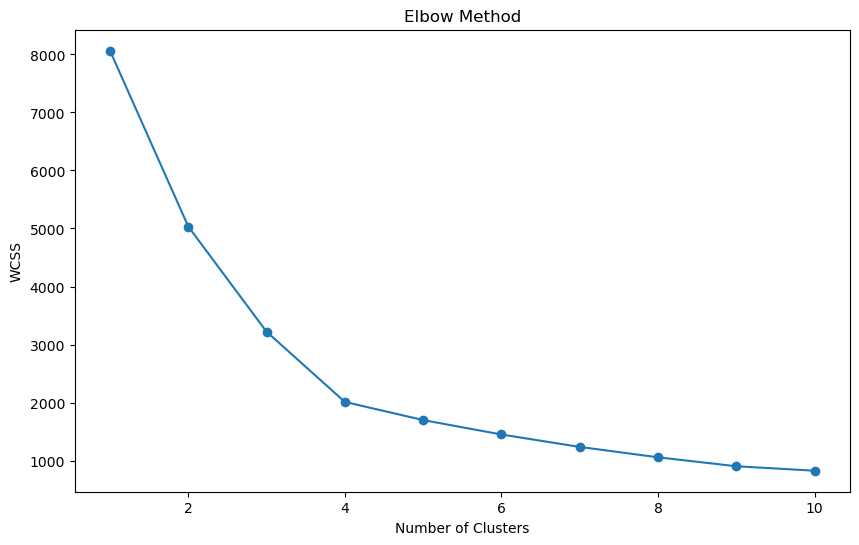

In [9]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt. show()

best_k = 3
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

4. Evaluate the model performance

In [11]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, df['cluster'])
print(f'Silhouette Score: {silhouette_avg:.2f}')

Silhouette Score: 0.38


5. Visualization

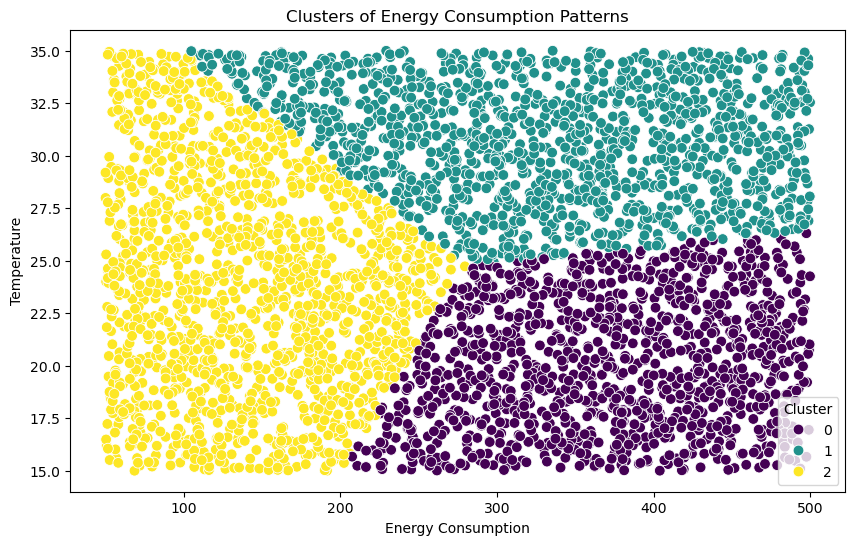

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='energy_consumption', y='temperature', hue='cluster' , data=df, palette='viridis', s=60)
plt.title('Clusters of Energy Consumption Patterns')
plt.xlabel('Energy Consumption')
plt.ylabel('Temperature')
plt.legend(title='Cluster')
plt.show()